In this notebook we will cover some of the basic quantum gates and how to express simple exponentials of Pauli operations in terms of these basic gates. If this seems all too easy for you, feel free to jump straight to the BONUS exercises at the end.

**NOTE**: the BONUS exercises at the end cover more advanced material which is not required to follow the classes at the school but could be useful if you want to learn more

### Packages

Before using this notebook make sure you install in your Python environment the following packages

- qiskit (versions 2.1.2 and 2.3.0 have been tested and work fine)
- qiskit-aer (version 0.17.2)
- pylatexenc

If you have trouble installing the packages on your machine, you can try to run this on [Colab](https://colab.research.google.com). In this case you will need to run the following cell to proceed with the installation

In [1]:
%pip install uv --quiet
!uv pip install --quiet \
    "qiskit==2.1.2" \
    "qiskit-aer==0.17.2"\
    pylatexenc

## Single qubit gates

Operations on a single qubit are unitary matrices in the group $U(2)$ but, since a global phase is not observable, we can restrict ourselves to the smaller $SU(2)$ group instead. An example of unitaries in $SU(2)$ that will come in handy very often are the Pauli gates

$$X=\begin{pmatrix}0&1\\1&0\end{pmatrix} \quad \quad Y=\begin{pmatrix}0&-i\\i&0\end{pmatrix} \quad\quad  Z=\begin{pmatrix}1&0\\0&-1\end{pmatrix}$$

For those of you that like Group Theory, part of the reason why these are useful is that they are a basis for the algebra $\mathcal{su}(2)$ of $SU(2)$ meaning that any single qubit gate can be thought to be an exponential of a linear combination of Pauli matrices.

A second set of very useful gates are the Hadamard gate $H$ and the Phase gate $S$ defined as follows

$$H=\frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}\quad\quad S=\begin{pmatrix}1&0\\0&i\end{pmatrix}=\sqrt{Z}$$

With the help of these gates we can make a change of basis between the eigenvectors of $Z$, also known as the **computational basis**, which are often denoted by $\rvert0\rangle$ and $\rvert1\rangle$, to the eigenbasis of either $X$ or $Y$. We have in fact that

$$X=HZH\quad\quad Y=S XS^\dagger = S HZHS^\dagger$$

This is particularly important in quantum computing since when we perform a projective measurement on the system we always do it in the **computational basis**. This allows a straightforward calculation of diagonal expectation values, like $\langle Z\rangle$, but if we want to estimate e.g. $\langle X\rangle$ we will need to explicitly change the basis. We will see an example below.

Another set of useful single qubit gates are rotations around $X$, $Y$ and $Z$ which can be obtained through exponentiation. For instance

$$R_X(\theta)=\exp\left(-i\frac{\theta}{2}X\right)=\begin{pmatrix} \cos(\theta/2)&-i\sin(\theta/2)\\-i\sin(\theta/2)&\cos(\theta/2)\end{pmatrix}$$

performs an $X$ rotation by an angle $\theta$. **Pay special attention to conventions like the sign of the exponent and the factor $1/2$ as they might change when you use gates implemented in different libraries**. For a complete documentation of the gates available through `qiskit` you can look at the documentation [here](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library).

### Example 1

In this first example we will write a circuit that prepares the single qubit state

$$\rvert\Psi(\theta)\rangle = \cos(\theta)\rvert0\rangle+\sin(\theta)\rvert1\rangle$$

and measuree the expectation value of the three Pauli matrices on the resulting state. The results are readily obtained to be

$$\langle \Psi(\theta) \lvert X \rvert \Psi(\theta)\rangle = 2\cos(\theta)\sin(\theta)=\sin(2\theta)$$
$$\langle \Psi(\theta) \lvert Y \rvert \Psi(\theta)\rangle = 0$$
$$\langle \Psi(\theta) \lvert Z \rvert \Psi(\theta)\rangle = \cos(\theta)^2-\sin(\theta)^2=\cos(2\theta)$$

Here's a simple Python snippet doing the explicit calculation in `numpy`

In [2]:
import numpy as np

## let's define the Pauli matrices
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1.j],[1.j,0]])
Z = np.array([[1,0],[0,-1]])
## specify the value of theta
theta = 0.2
## perform calculation
psi = np.array([np.cos(theta),np.sin(theta)])
print(f"<X>: {np.vdot(psi,X@psi)}\t{np.sin(2*theta)}")
print(f"<Y>: {np.vdot(psi,Y@psi)}\t{0}")
print(f"<Z>: {np.vdot(psi,Z@psi)}\t{np.cos(2*theta)}")

<X>: 0.38941834230865047	0.3894183423086505
<Y>: 0j	0
<Z>: 0.9210609940028851	0.9210609940028851


And here is a version using `qiskit` instead

Using Qiskit 2.1.2
Using Qiskit AER 0.17.2


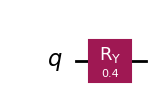

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.version import get_version_info
print(f"Using Qiskit {get_version_info()}")
from qiskit_aer.version import get_version_info
print(f"Using Qiskit AER {get_version_info()}")
## specify the value of theta
theta = 0.2
## build single qubit circuit
circ = QuantumCircuit(1)
## let's get a handle for the qubit we have
quantum_bits = circ.qubits
## here we use a R_Y gate on qubit 0 (pay attention to the factor of 1/2!)
circ.ry(2*theta,quantum_bits[0])
## let's visualize what we did
circ.draw('mpl')
## the command above requires pylatexenc, if you do not have it you can use the following instead
#print(circ.draw('text'))

We can now try to measure the expectation values using a `state-vector' simulation

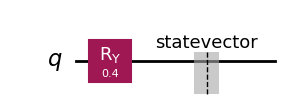

In [4]:
circ_sv = circ.copy()
circ_sv.save_statevector()
circ_sv.draw('mpl')

In [5]:
## run simulator and extract resulting vector
sim_statevector = AerSimulator(method='statevector')
job_sv = sim_statevector.run(circ_sv)
result_sv = job_sv.result()
outputstate_sv = result_sv.get_statevector(circ_sv, decimals=8)
print(outputstate_sv)

Statevector([0.98006658+0.j, 0.19866933+0.j],
            dims=(2,))


In [6]:
## we can convert the result into a standard numpy array
psi_sv = np.array(outputstate_sv.data.tolist())
print(psi_sv)
## and compute the resulting expectation values
print(f"<X>: {np.vdot(psi_sv,X@psi_sv)}\t{np.sin(2*theta)}")
print(f"<Y>: {np.vdot(psi_sv,Y@psi_sv)}\t{0}")
print(f"<Z>: {np.vdot(psi_sv,Z@psi_sv)}\t{np.cos(2*theta)}")

[0.98006658+0.j 0.19866933+0.j]
<X>: (0.38941834160798283+0j)	0.3894183423086505
<Y>: 0j	0
<Z>: (0.9210609985502475+0j)	0.9210609940028851


NOTE: within `qiskit` there are a variety of ways to estimate expectation values directly from the Statevector object without going through `numpy`.

Using changes of basis we can obtain instead the same expectation values by measuring only $Z$ on rotated circuits

In [7]:
## for X we need an Hadamard
circ_x = circ.copy()
circ_x.h(0)
circ_x.save_statevector()
print(circ_x.draw('text'))
## run calculation
job_x = sim_statevector.run(circ_x)
result_x = job_x.result()
outputstate_x = result_x.get_statevector(circ_x, decimals=8)
psi_x = np.array(outputstate_x.data.tolist())
## note that now we are measuring Z on the rotated state
print(f"<X>: {np.vdot(psi_x,Z@psi_x)}\t{np.sin(2*theta)}")

   ┌─────────┐┌───┐ statevector 
q: ┤ Ry(0.4) ├┤ H ├──────░──────
   └─────────┘└───┘      ░      
<X>: (0.3894183376825583+0j)	0.3894183423086505


In [8]:
## for Y we need an S^dagger and then an Hadamard
circ_y = circ.copy()
circ_y.sdg(0)
circ_y.h(0)
circ_y.save_statevector()
print(circ_y.draw('text'))
## run calculation
job_y = sim_statevector.run(circ_y)
result_y = job_y.result()
outputstate_y = result_y.get_statevector(circ_y, decimals=8)
psi_y = np.array(outputstate_y.data.tolist())
## note that now we are measuring Z on the rotated state
print(f"<Y>: {np.vdot(psi_y,Z@psi_y)}\t{0}")

   ┌─────────┐┌─────┐┌───┐ statevector 
q: ┤ Ry(0.4) ├┤ Sdg ├┤ H ├──────░──────
   └─────────┘└─────┘└───┘      ░      
<Y>: 0j	0


In [9]:
## for Z we are good to go
circ_z = circ.copy()
circ_z.save_statevector()
print(circ_z.draw('text'))
## run calculation
job_z = sim_statevector.run(circ_z)
result_z = job_z.result()
outputstate_z = result_z.get_statevector(circ_z, decimals=8)
psi_z = np.array(outputstate_z.data.tolist())
## note that now we are measuring Z on the rotated state
print(f"<Z>: {np.vdot(psi_z,Z@psi_z)}\t{np.cos(2*theta)}")

   ┌─────────┐ statevector 
q: ┤ Ry(0.4) ├──────░──────
   └─────────┘      ░      
<Z>: (0.9210609985502475+0j)	0.9210609940028851


- **EXERCISE 1**: try to implement this using the QASM simulator and estimate the statistical errors on the expectation values

## Multi qubit gates

When we have more than a single qubit we have at our disposal a larger group of transformations. An examples of a two qubit gate is the following

$$CNOT = \begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\\\end{pmatrix} = \rvert0\rangle\langle0\lvert\otimes\mathbb{1}+\rvert1\rangle\langle1\lvert\otimes X$$

Which in circuit notation looks like

          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
or also


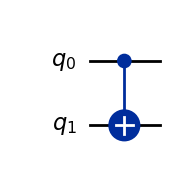

In [10]:
circ2a = QuantumCircuit(2)
circ2a.cx(0,1)
print(circ2a.draw('text'))
print("or also")
circ2a.draw('mpl')

The notation for the $CNOT$ gate in the 'text' version makes it apparent that this operation has something to do with the Pauli $X$ gate. The line joining the two qubits indicates a **control**: the operation $X$ is performed on the qubit `q_1` only if the qubit `q_0` is in the $\rvert0\rangle$ state. More explicitly

$$CNOT\rvert00\rangle=\rvert00\rangle$$
$$CNOT\rvert01\rangle=\rvert01\rangle$$
$$CNOT\rvert10\rangle=\rvert11\rangle$$
$$CNOT\rvert11\rangle=\rvert10\rangle$$

The notation makes it also clear that the $CNOT$ operation is directional and we should really write it as $CNOT(q_c,q_t)$ where $q_c$ is the control qubit and $q_t$ the target qubit. The operation we implemented above is therefore, more explictly, $CNOT(q_0,q_1)$. Unsurprisingly $CNOT(q_1,q_0)$ looks instead like this

     ┌───┐
q_0: ┤ X ├
     └─┬─┘
q_1: ──■──
          
or also


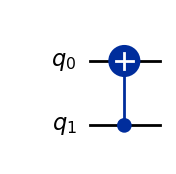

In [11]:
circ2b = QuantumCircuit(2)
circ2b.cx(1,0)
print(circ2b.draw('text'))
print("or also")
circ2b.draw('mpl')

Controlled operations are everywhere in quantum computing as they allow us to express compactly complex operations. Some of the manipulations we do on them are rather intuitive. For instance if we wanted to perform a controlled $Z$ operation from `q_0` to `q_1` instead we could do

                    
q_0: ───────■───────
     ┌───┐┌─┴─┐┌───┐
q_1: ┤ H ├┤ X ├┤ H ├
     └───┘└───┘└───┘
or also


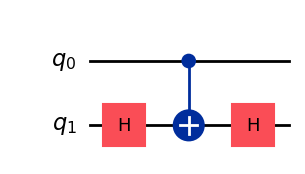

In [12]:
circ2c = QuantumCircuit(2)
circ2c.h(1)
circ2c.cx(0,1)
circ2c.h(1)
print(circ2c.draw('text'))
print("or also")
circ2c.draw('mpl')

As the Hadamerd gates are making the change of basis between $X$ and $Z$ for us. This operation is common enough (and in fact is the one actually being implemented in some hardware platforms) that has a name which, unsurprisingly, is $CZ$ and is directly available from `qiskit`

        
q_0: ─■─
      │ 
q_1: ─■─
        
or also


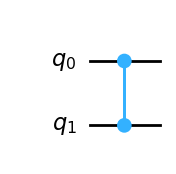

In [13]:
circ2d = QuantumCircuit(2)
circ2d.cz(0,1)
print(circ2d.draw('text'))
print("or also")
circ2d.draw('mpl')

This notation makes it apparent that $CZ(q_c,q_t)=CZ(q_t,q_c)$, i.e. this operation is not directional.

It is maybe a surprise that once we have either $CZ$ or $CNOT$ and the single qubit rotations discussed above we can implement **any** two-qubit operation we like. For any unitary in $SU(4)$ we in fact only need $3$ CNOT to implement it (see e.g. [here](https://arxiv.org/pdf/quant-ph/0307177) and [here](https://arxiv.org/pdf/quant-ph/0308006)). Perhaps more surprising is the fact that for any number $n$ of qubits we can exactly implement any $SU(2^n)$ unitary transformation purely in terms of $CNOT$ gates and single qubit operations i.e. they constitute a **universal gate set** (see e.g. [here](https://arxiv.org/pdf/cond-mat/9407022) and [here](https://arxiv.org/pdf/quant-ph/9505016)). Even more surprisingly, we can approximate any unitary in $SU(2^n)$ efficiently even if we restrict the single qubit gates to only $H$ and $\sqrt{S}$ (see e.g. [here](https://arxiv.org/pdf/quant-ph/0403025), [here](https://arxiv.org/pdf/quant-ph/0505030) and [here](https://arxiv.org/pdf/1403.2975)). This means we can, at least in principle, have an actual **universal quantum computer** since with a finite number of gates we can approximate arbitrarily well a continuous set of possible transformations.

- **EXERCISE 2**: try to show that the following circuit is equivalent to $CNOT(q_1,q_0)$

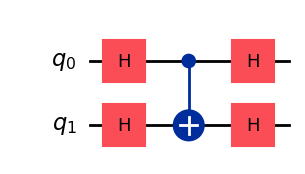

In [14]:
circ_e2 = QuantumCircuit(2)
circ_e2.h(0)
circ_e2.h(1)
circ_e2.cx(0,1)
circ_e2.h(0)
circ_e2.h(1)
circ_e2.draw('mpl')

- **EXERCISE 3**: try to show that the following circuit is equivalent to a controlled $Z$ rotation of the form
$$CR_Z(\theta)=\begin{pmatrix}\mathbb{1}&0\\0&R_Z(\theta)\\\end{pmatrix}$$
where the individual blocks here are meant to be $2\times2$ matrices. How would you change the circuit to perform $CR_X(\theta)$ instead?

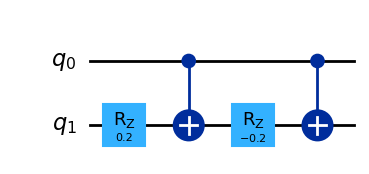

In [15]:
## here theta can be any angle of your choosing
theta = 0.2
circ_e3 = QuantumCircuit(2)
circ_e3.rz(theta/2,1)
circ_e3.cx(0,1)
circ_e3.rz(-theta/2,1)
circ_e3.cx(0,1)
circ_e3.draw('mpl')

All of these constructions can of course be generalized to gates acting on multiple qubits instead. For instance here is an example of a three qubit gate that generalizes the $CNOT$ gate and is called the Toffoli gate

$$TOFF = \begin{pmatrix}
1&0&0&0&0&0&0&0\\
0&1&0&0&0&0&0&0\\
0&0&1&0&0&0&0&0\\
0&0&0&1&0&0&0&0\\
0&0&0&0&1&0&0&0\\
0&0&0&0&0&1&0&0\\
0&0&0&0&0&0&0&1\\
0&0&0&0&0&0&1&0\\
\end{pmatrix} = \left(\rvert00\rangle\langle00\lvert+\rvert01\rangle\langle01\lvert+\rvert10\rangle\langle10\lvert\right)\otimes\mathbb{1}+\rvert11\rangle\langle11\lvert\otimes X$$

Which in circuit notation look like

          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
or also


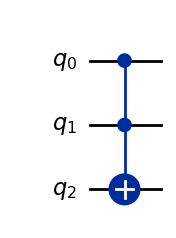

In [16]:
circ3a = QuantumCircuit(3)
circ3a.ccx(0,1,2)
print(circ3a.draw('text'))
print("or also")
circ3a.draw('mpl')

- **EXERCISE 4**: can you tell what operation does this circuit do? The answer does not depend on the input state

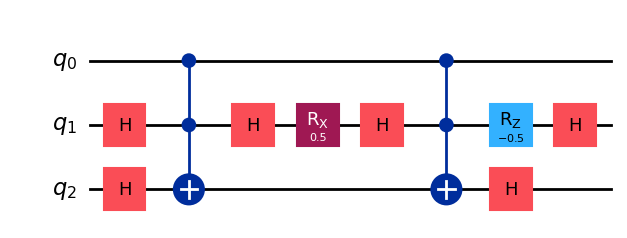

In [17]:
circ_e4 = QuantumCircuit(3)
circ_e4.h([1,2])
circ_e4.ccx(0,1,2)
circ_e4.h(1)
circ_e4.rx(0.5,1)
circ_e4.h(1)
circ_e4.ccx(0,1,2)
circ_e4.rz(-0.5,1)
circ_e4.h([1,2])
circ_e4.draw('mpl')

- **EXERCISE 5**: how about this one? Can you show that the result remains the same regardless of the choice of the rotation angles $\theta$ and $\phi$?
    - **NOTE** Keep in mind that when we execute this circuit all of the qubits start in $\rvert0\rangle$

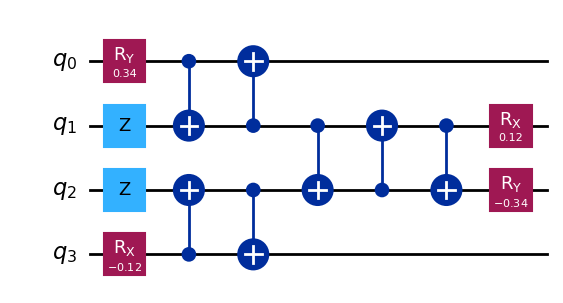

In [18]:
theta=0.34
phi=0.12

circ_e5 = QuantumCircuit(4)
circ_e5.ry(theta,0)
circ_e5.z([1,2])
circ_e5.rx(-phi,3)
circ_e5.cx(0,1)
circ_e5.cx(3,2)
circ_e5.cx(1,0)
circ_e5.cx(2,3)
circ_e5.cx(1,2)
circ_e5.cx(2,1)
circ_e5.cx(1,2)
circ_e5.ry(-theta,2)
circ_e5.rx(phi,1)
circ_e5.draw('mpl')

**HINTS**:
- try to chose a simple pair of angles so that you can find the final state easily. What do you get?
- to understand better what is happening you might want to consider the following sub-circuit. What is this doing if you enter with an arbitrary two qubit state?

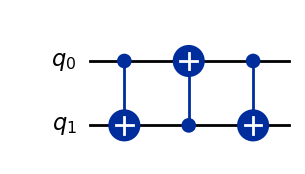

In [19]:
circ_e5p = QuantumCircuit(2)
circ_e5p.cx(0,1)
circ_e5p.cx(1,0)
circ_e5p.cx(0,1)
circ_e5p.draw('mpl')

## Exponentials of Pauli matrices

We have already encountered the single qubit rotations corresponding to exponentials of Pauli matrices. What happend if instead we want a multi-qubit 'rotation' like the following ones

$$U_A(\theta)=\exp(-i\theta Z_0Z_1)\quad U_B(\theta)=\exp(-i\theta X_0X_2)\quad U_C(\theta)=\exp(-i\theta X_0X_1X_2)\quad U_D(\theta)=\exp(-i\theta X_0Z_1Y_2)$$

The idea behind the implementation of these operations is really simple and it all boils down to two very useful circuit identities
- whenever you move a $Z$ gate past the **control** of a $CNOT$ you can simply do that
- whenever you move a $Z$ gate past the **target** of a $CNOT$ you get two $Z$ gates on both control and target
In circuits these look like

In [20]:
circ_ep1a = QuantumCircuit(2)
circ_ep1a.z(0)
circ_ep1a.cx(0,1)
print("This circuit")
print(circ_ep1a.draw('text'))
circ_ep1b = QuantumCircuit(2)
circ_ep1b.cx(0,1)
circ_ep1b.z(0)
print("is equal to this circuit")
print(circ_ep1b.draw('text'))
print("Regardless of the input state")

This circuit
     ┌───┐     
q_0: ┤ Z ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
is equal to this circuit
          ┌───┐
q_0: ──■──┤ Z ├
     ┌─┴─┐└───┘
q_1: ┤ X ├─────
     └───┘     
Regardless of the input state


In [21]:
circ_ep1c = QuantumCircuit(2)
circ_ep1c.z(1)
circ_ep1c.cx(0,1)
print("This circuit")
print(circ_ep1c.draw('text'))
circ_ep1d = QuantumCircuit(2)
circ_ep1d.cx(0,1)
circ_ep1d.z([0,1])
print("is equal to this circuit")
print(circ_ep1d.draw('text'))
print("Regardless of the input state")

This circuit
               
q_0: ───────■──
     ┌───┐┌─┴─┐
q_1: ┤ Z ├┤ X ├
     └───┘└───┘
is equal to this circuit
          ┌───┐
q_0: ──■──┤ Z ├
     ┌─┴─┐├───┤
q_1: ┤ X ├┤ Z ├
     └───┘└───┘
Regardless of the input state


Try to use these identities to show that $U_A(\theta)$ can be implemented with either of these circuits

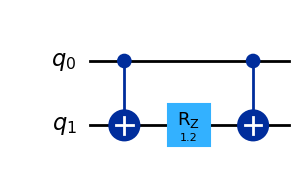

In [22]:
## here we pick some value for theta just for the example (the value does not matter)
theta=0.6
circ_ua1 = QuantumCircuit(2)
circ_ua1.cx(0,1)
circ_ua1.rz(2*theta,1)
circ_ua1.cx(0,1)
circ_ua1.draw('mpl')

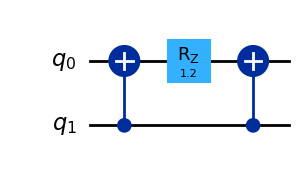

In [23]:
## here we pick some value for theta just for the example (the value does not matter)
theta=0.6
circ_ua2 = QuantumCircuit(2)
circ_ua2.cx(1,0)
circ_ua2.rz(2*theta,0)
circ_ua2.cx(1,0)
circ_ua2.draw('mpl')

- **EXERCISE 6**: try to use what you learned above to implement circuits for the other operations on a three qubit system. Try to find as many equivalent implementations as possible and test they perform the correct operation by performing state-vector simulations and comparing them to what you obtain by computing the exact evolution using `numpy`


A couple of very good references for basic circuit implementations and circuit manipulations are [this one](https://arxiv.org/pdf/quant-ph/9503016) and [this one](https://arxiv.org/abs/1110.2998). Note that many of the techniques explained in the first of these are mostly useful pedagogically but there are now much more efficient modern techniques to compile circuits. If you are curious you can take a look for instance [here](https://arxiv.org/abs/1003.5760) and [here](https://arxiv.org/abs/2510.07223) to get a flavor of more recent work on gate compilation.

### BONUS EXERCISE 1: quantum state teleportation
Quantum teleportation is an interesting communication protocol where information is transmitted between a sender, we'll call her Sandy, and a receiver, will call him Rick,  through a combination of entanglement and classical communication. The protocol works as follows:

- Sandy has one qubit, we'll call $B_\Psi$, in a state that she wants to send to Rick. For this example we'll use $\rvert \Psi(\theta)\rangle$ from Example 1 above
- before the protocol began, Sandy and Rick prepare a two qubit Bell state $\rvert B\rangle=(\rvert 00\rangle+\rvert 11\rangle)/\sqrt{2}$. By keeping one qubit each, let's call $B_S$ and $B_R$, they can now use as a resource for communication.
- the protocol now proceeds as follows:
    1. Sandy entangles her qubit $B_\Psi$ with her part of the Bell state on qubit $B_S$. The total state on qubits $(B_\Psi,B_S,B_R)$ is then
$$\frac{\cos(\theta)}{\sqrt{2}}\rvert 0\rangle\otimes\left(\rvert 00\rangle+\rvert 11\rangle\right)+\frac{\sin(\theta)}{\sqrt{2}}\rvert 1\rangle\otimes\left(\rvert 10\rangle+\rvert 01\rangle\right)$$
    2. she applies an Hadamard gate to her qubit $B_\Psi$ obtaining
$$\frac{\rvert 00\rangle}{2}\otimes\left(\cos(\theta)\rvert 0\rangle+\sin(\theta)\rvert 1\rangle\right)
            +            \frac{\rvert 01\rangle}{2}\otimes\left(\cos(\theta)\rvert1\rangle+\sin(\theta)\rvert 0\rangle\right)
            \frac{\rvert 10\rangle}{2}\otimes\left(\cos(\theta)\rvert 0\rangle-\sin(\theta)\rvert 1\rangle\right)
            +            \frac{\rvert 11\rangle}{2}\otimes\left(\cos(\theta)\rvert 1\rangle-\sin(\theta)\rvert 0\rangle\right)$$
    3. she measures their qubits and send the outcomes to Rick
    4. Rick can then recover the unknown state $\rvert \Psi\rangle$ on his qubit $B_R$ by performing on it a specific Pauli transformation depending on the measurement outcome
       - no operation if results is $(B_\Psi,B_S)=(0,0)$
       - Pauli $X$ if results is $(B_\Psi,B_S)=(0,1)$
       - Pauli $Z$ if results is $(B_\Psi,B_S)=(1,0)$
       - Pauli $XZ$ if results is $(B_\Psi,B_S)=(1,1)$

Try to show that indeed the state on Rick's qubit $B_R$ is the correct one. Then try to implement this protocol with `qiskit`. For instance you can try to measure qubit $B_R$ after the whole protocol has ended and compare the results with those you would've expected if you had the correct state $\rvert \Psi(\theta)\rangle$. You can use the following code-snippet to get started

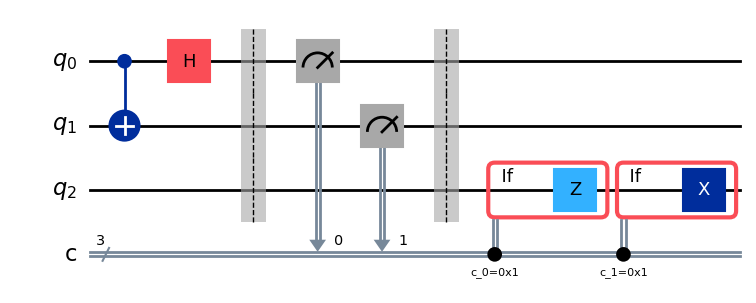

In [24]:
# defines a circuit with 3 qubits and 3 classical bits
telep_circ = QuantumCircuit(3,3)
# stores labels for the 3 qubits
quantum_bits = telep_circ.qubits
# stores labels for the 3 classical bits (for mesaurements)
classical_bits = telep_circ.clbits
# performs CNOT to entangle qubits and Hadamard on B_psi
telep_circ.cx(quantum_bits[0],quantum_bits[1])
telep_circ.h(quantum_bits[0])
# measurement
telep_circ.barrier()
telep_circ.measure(quantum_bits[0],classical_bits[0])
telep_circ.measure(quantum_bits[1],classical_bits[1])
# classical control
telep_circ.barrier()
## apply a Z to qubit B_R if measure on c_psi is 1.
with telep_circ.if_test((classical_bits[0],1)):
    telep_circ.z(quantum_bits[2])
## apply an X to qubit B_R if measure on c_S is 1.
with telep_circ.if_test((classical_bits[1],1)):
    telep_circ.x(quantum_bits[2])
telep_circ.draw('mpl')

### BONUS EXERCISE 2

If you already know everything about `qiskit`, circuits and quantum teleportation try to use your skills to understand what this circuit is doing

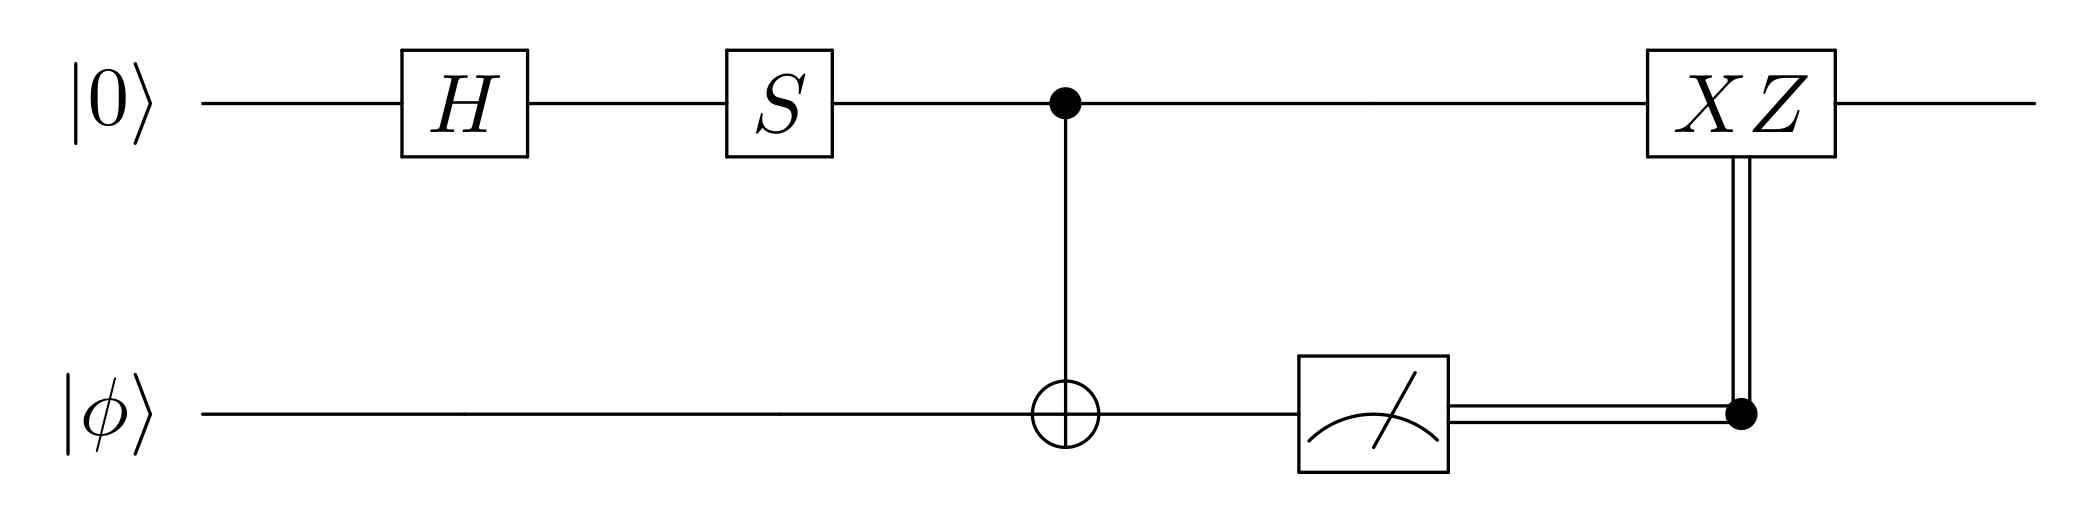

The $\rvert\phi\rangle$ on the second qubit is completely generic and the double lines are used for classical controls (like above for state teleportation).

- try to understand what state is left on the first qubit
- can you find a way to achieve the same functionality but without measuring the second qubit at all?
- and how about a version without any controls **after** the measurement?
- if in the original circuit instead of the gates $S$ we used $T=\sqrt{S}$, what classically controlled operation should we use to get the same type of functionality?
- why would a circuit like this be useful?

The second and fourth question are the toughest. A hint for the latter is that $T$ gates are really difficult to implement with active error correction. A hint for the former is to check out, if you never heard of it, what **oblivious amplitude amplification** is [here](https://arxiv.org/pdf/1312.1414) or [here](https://arxiv.org/abs/1412.4687).